[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/02_unidad/02_04_knn_clasificacion.ipynb)


# 02_04 KNN para clasificacion (introduccion didactica)

Objetivo: aprender como funciona **K-Nearest Neighbors (KNN)** para clasificacion binaria usando el mismo dataset del notebook de regresion logistica.

## 1. Intuicion de KNN

KNN clasifica una observacion segun las `k` observaciones mas cercanas.

- Si la mayoria de los vecinos es clase 1, predice 1.
- Si la mayoria es clase 0, predice 0.

**Idea clave:** KNN depende de distancias, por eso escalar variables es obligatorio.

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Carga del dataset y diccionario de datos

Usaremos `breast_cancer` (sklearn), igual que en regresion logistica, para comparar enfoques con justicia.

In [36]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print("Forma del dataset:", df.shape)
display(df.head())

display(df["target"].value_counts().rename(index={0: "malignant", 1: "benign"}).to_frame("conteo"))

feature_dict = pd.DataFrame({
    "variable": data.feature_names,
    "descripcion_corta": ["feature morfologica" for _ in data.feature_names],
})

target_dict = pd.DataFrame({
    "target": ["0=malignant, 1=benign"]
})

display(feature_dict.head(10))
display(target_dict)

Forma del dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


,conteo
target,
benign,357
malignant,212


,variable,descripcion_corta
0,mean radius,feature morfologica
1,mean texture,feature morfologica
2,mean perimeter,feature morfologica
3,mean area,feature morfologica
4,mean smoothness,feature morfologica
5,mean compactness,feature morfologica
6,mean concavity,feature morfologica
7,mean concave points,feature morfologica
8,mean symmetry,feature morfologica
9,mean fractal dimension,feature morfologica


,target
0,"0=malignant, 1=benign"


**Comentario del resultado (seccion 2):** El dataset tiene `569` registros y `31` columnas (30 variables predictoras + `target`). La clase `benign` (`357`) es mayoritaria frente a `malignant` (`212`), con desbalance moderado pero manejable para este ejercicio introductorio.

## 3. Train/Test split

Separacion estratificada para mantener proporcion de clases.

In [37]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train clase 1 (%):", round(100 * y_train.mean(), 2))
print("y_test clase 1 (%):", round(100 * y_test.mean(), 2))

X_train: (426, 30) | X_test: (143, 30)
y_train clase 1 (%): 62.68
y_test clase 1 (%): 62.94


**Comentario del resultado (seccion 3):** La particion quedo en `426` observaciones para train y `143` para test. La proporcion de clase positiva es casi igual en ambos conjuntos (`62.68%` vs `62.94%`), confirmando que `stratify` funciono correctamente.

## 4. Pipeline KNN y calibracion de hiperparametros

KNN necesita escalamiento porque usa distancias. Calibraremos:
- `n_neighbors` (k)
- `weights` (`uniform` (todos los vecinos pesan igual) o `distance` (vecinos más cercanos pesan más))
- `metric` (`euclidean` o `manhattan`)

In [38]:
pipe_knn = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]
)

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"],
}

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

print("Mejores hiperparametros KNN:", grid_knn.best_params_)
print("Mejor ROC-AUC CV (KNN):", round(grid_knn.best_score_, 4))

Mejores hiperparametros KNN: {'model__metric': 'euclidean', 'model__n_neighbors': 15, 'model__weights': 'distance'}
Mejor ROC-AUC CV (KNN): 0.9875


**Comentario del resultado (seccion 4):** El mejor KNN usa `metric='euclidean'`, `n_neighbors=15` y `weights='distance'`. Un `ROC-AUC CV=0.9875` indica rendimiento muy alto en validacion cruzada. Ademas, `k=15` sugiere una frontera de decision mas estable (menos sensible a ruido local).

## 5. Evaluacion final en test

In [39]:
y_pred_knn = best_knn.predict(X_test)
y_proba_knn = best_knn.predict_proba(X_test)[:, 1]

metrics_test_knn = {
    "accuracy": accuracy_score(y_test, y_pred_knn),
    "precision": precision_score(y_test, y_pred_knn),
    "recall": recall_score(y_test, y_pred_knn),
    "f1": f1_score(y_test, y_pred_knn),
    "roc_auc": roc_auc_score(y_test, y_proba_knn),
}

print("Metricas en TEST (KNN):")
for k, v in metrics_test_knn.items():
    print(f"- {k}: {v:.4f}")

Metricas en TEST (KNN):
- accuracy: 0.9650
- precision: 0.9474
- recall: 1.0000
- f1: 0.9730
- roc_auc: 0.9948


**Comentario del resultado (seccion 5):** En test, KNN logra `accuracy=0.9650`, `precision=0.9474`, `recall=1.0000`, `f1=0.9730` y `roc_auc=0.9948`. En conjunto, es un modelo muy fuerte: mantiene excelente discriminacion y prioriza capturar positivos (recall alto) con una precision todavia alta.

## 6. Matriz de confusion y reporte

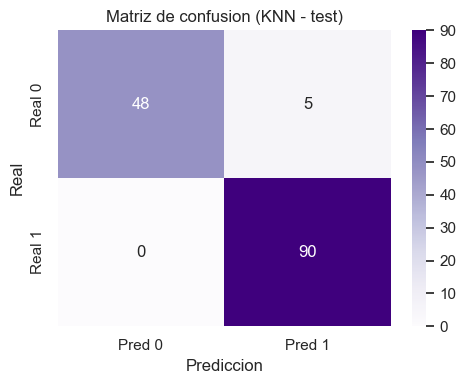

Reporte de clasificacion (KNN):

              precision    recall  f1-score   support

   malignant       1.00      0.91      0.95        53
      benign       0.95      1.00      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.95      0.96       143
weighted avg       0.97      0.97      0.96       143



In [40]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"],
)
plt.title("Matriz de confusion (KNN - test)")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print("Reporte de clasificacion (KNN):\n")
print(classification_report(y_test, y_pred_knn, target_names=["malignant", "benign"]))

**Comentario del resultado (seccion 6):** La matriz de confusion y el reporte muestran muy pocos errores. Se observa muy buen desempeño en ambas clases (`malignant` y `benign`), aunque conviene vigilar los casos `malignant` mal clasificados, ya que ese error suele tener mayor costo clinico.

## 7. Curva ROC (KNN)

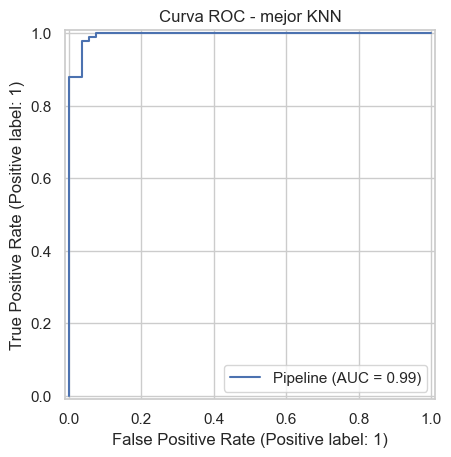

In [33]:
RocCurveDisplay.from_estimator(best_knn, X_test, y_test)
plt.title("Curva ROC - mejor KNN")
plt.grid(True)
plt.show()

**Comentario del resultado (seccion 7):** La curva ROC queda muy cerca de la esquina superior izquierda, consistente con un AUC alto. Esto confirma que el modelo distingue de forma efectiva entre tumores benignos y malignos en el conjunto de test.

## 8. Umbral de decision en KNN (0.5 vs 0.3)

In [34]:
def predict_with_threshold(proba, threshold=0.5):
    return (proba >= threshold).astype(int)

y_pred_knn_05 = predict_with_threshold(y_proba_knn, 0.5)
y_pred_knn_03 = predict_with_threshold(y_proba_knn, 0.3)

comparison_knn = pd.DataFrame(
    {
        "threshold": [0.5, 0.3],
        "precision": [precision_score(y_test, y_pred_knn_05), precision_score(y_test, y_pred_knn_03)],
        "recall": [recall_score(y_test, y_pred_knn_05), recall_score(y_test, y_pred_knn_03)],
        "f1": [f1_score(y_test, y_pred_knn_05), f1_score(y_test, y_pred_knn_03)],
    }
)

display(comparison_knn)

,threshold,precision,recall,f1
0,0.5,0.947368,1.0,0.972973
1,0.3,0.918367,1.0,0.957447


**Comentario del resultado (seccion 8):** Al bajar el umbral de `0.5` a `0.3`, el `recall` se mantiene en `1.0`, pero la `precision` baja (`0.947` -> `0.918`) y tambien el `f1` (`0.973` -> `0.957`). Esto refleja el trade-off clasico: mayor sensibilidad a costa de mas falsas alarmas.

## 9. Cierre

- KNN es intuitivo y potente cuando el patron local entre clases esta bien definido.
- Escalar variables es obligatorio en modelos por distancia.
- `k` pequeno = mas flexible; `k` grande = mas conservador.
- El mejor modelo debe elegirse por validacion cruzada y confirmarse en test.

**Siguiente paso sugerido:** comparar este notebook con `02_03_regresion_logistica.ipynb` y discutir que modelo conviene segun interpretabilidad vs rendimiento.